# Customer Churn Prediction
## Phase 3 — Exploratory Data Analysis

1. Import Libraries
2. Load Data
3. Dataset Overview
4. Data Quality
5. Target Variable Analysis
6. Univariate Analysis
7. Bivariate Analysis
8. Numerical Analysis
9. Categorical Analysis
10. Multivariate Analysis
11. Correlation Analysis
12. Outlier Analysis
13. EDA Insights
14. Modeling Preparation Notes

Libraries imported successfully
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  704

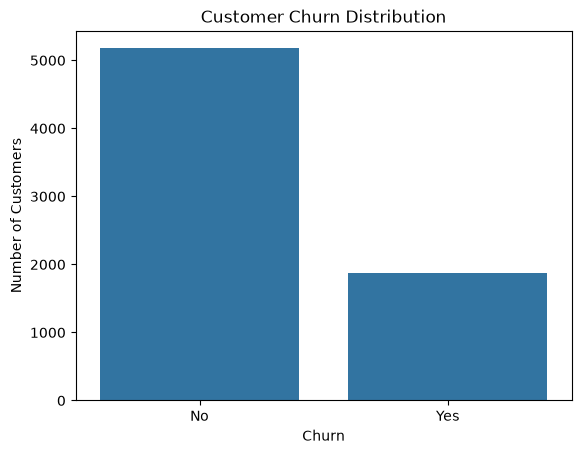

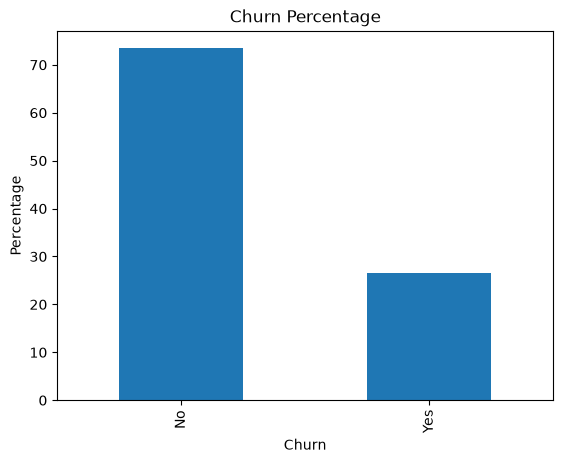

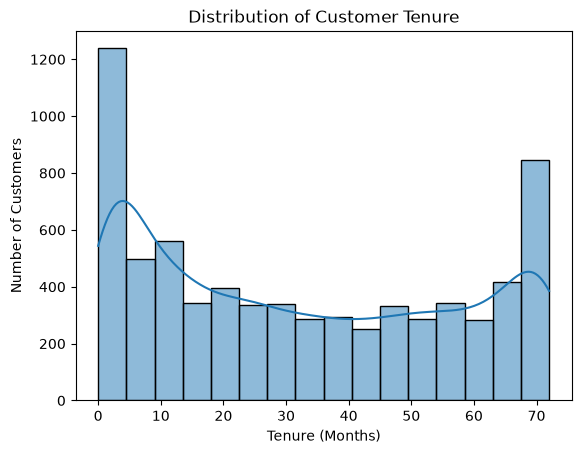

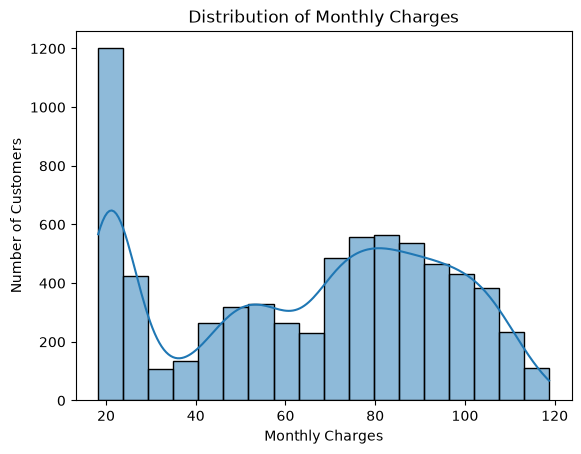

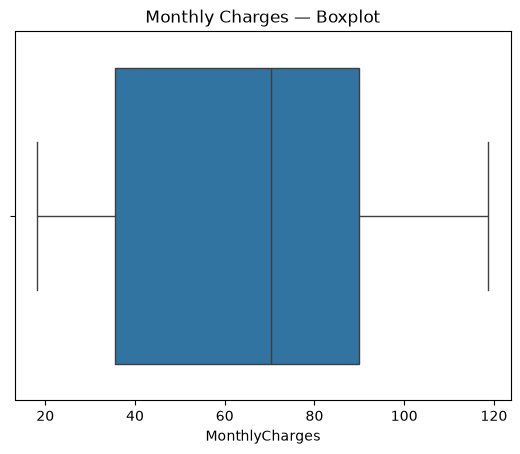

C:\Users\ckaus\AppData\Local\Temp\ipykernel_24964\381345438.py:77: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


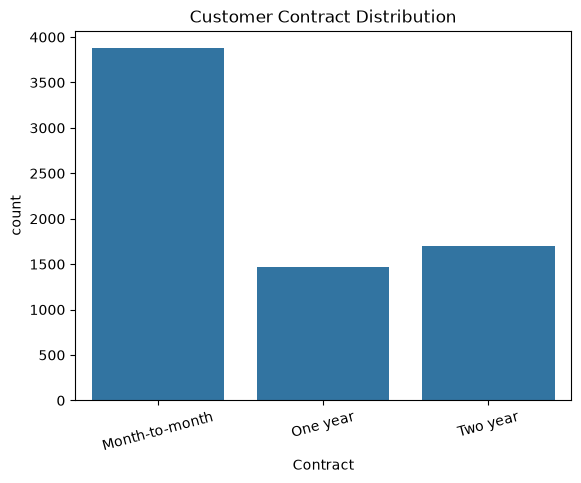

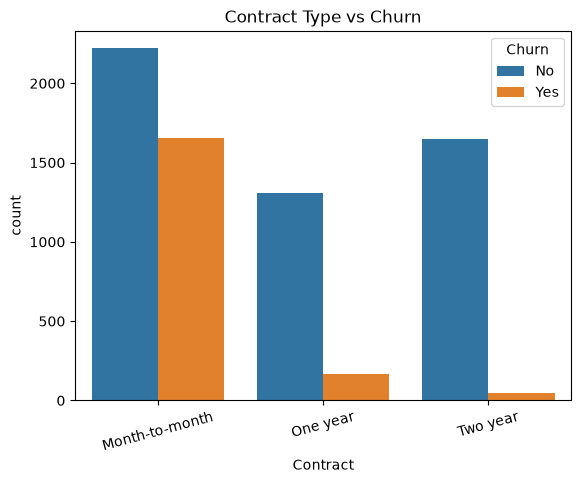

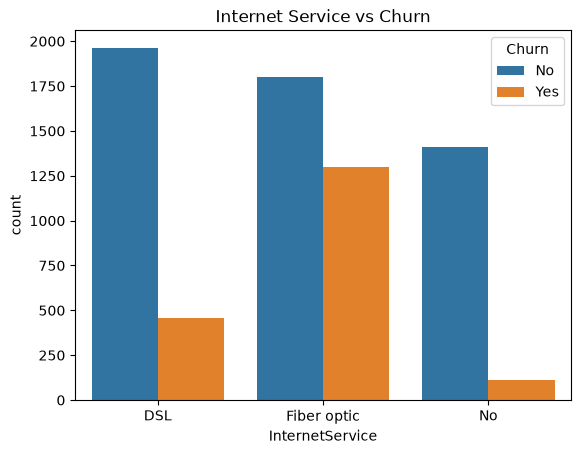

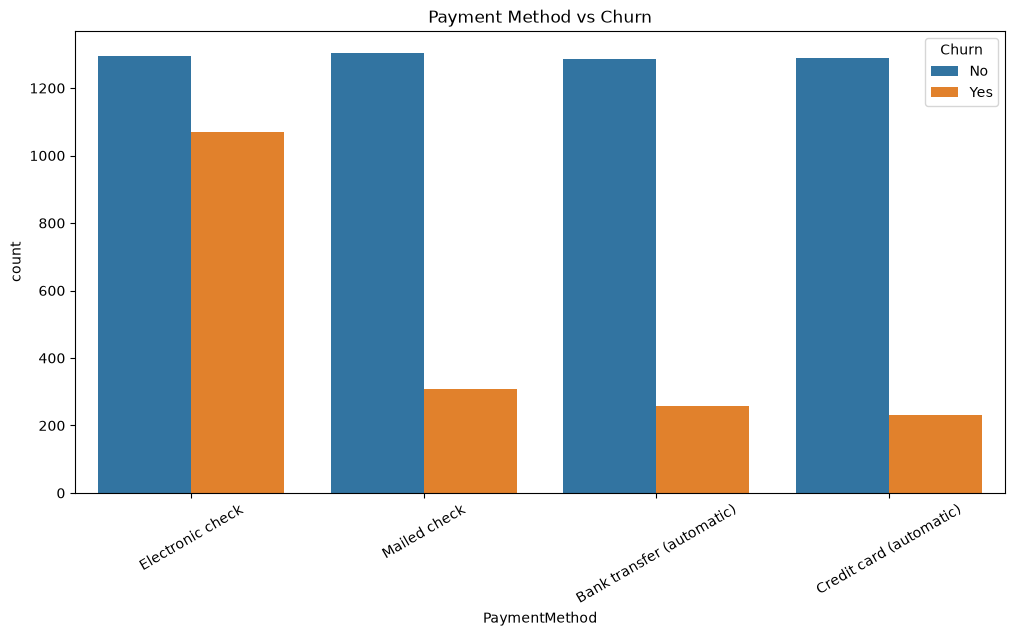

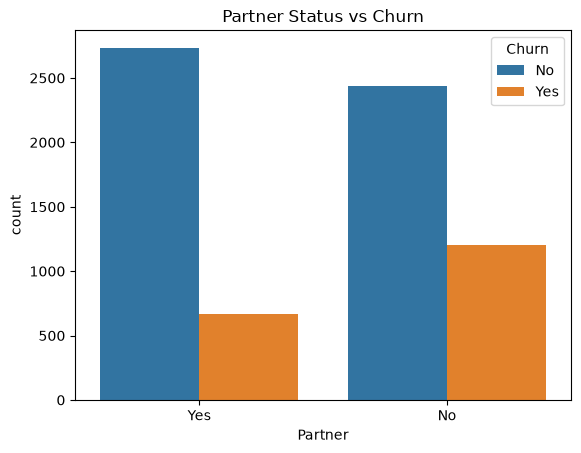

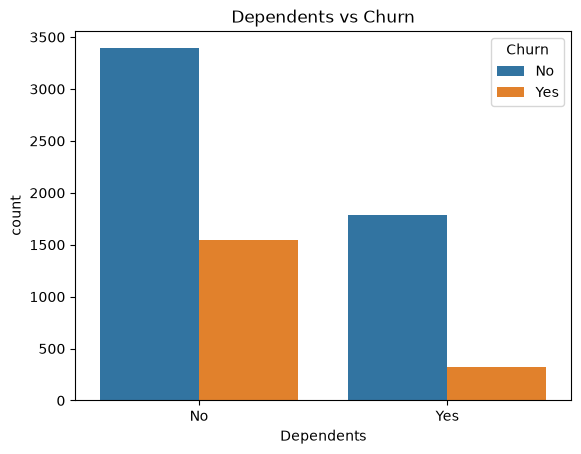

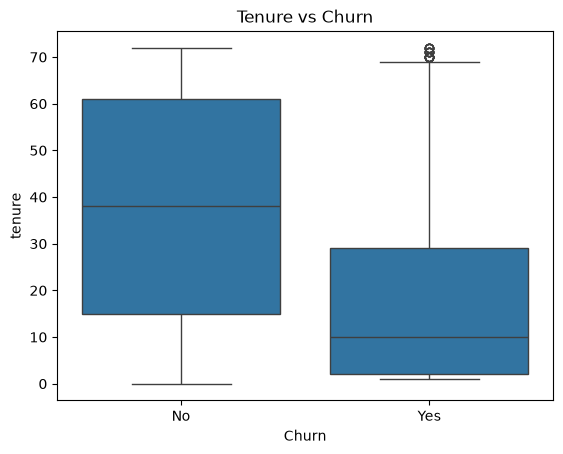

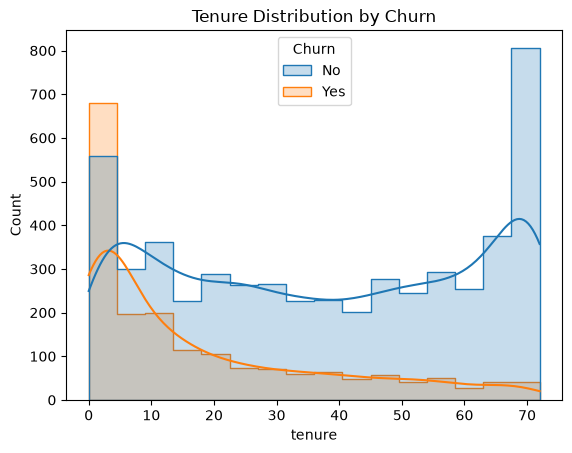

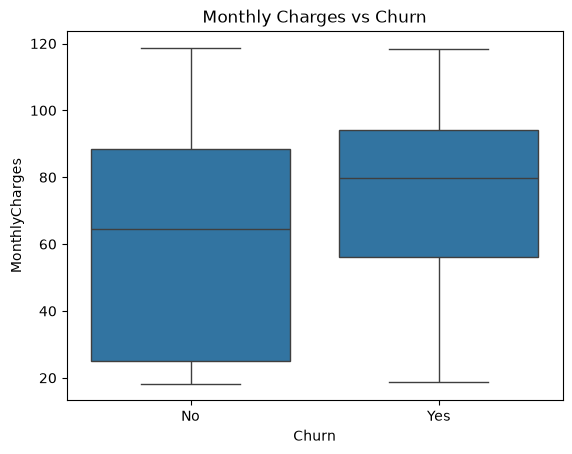

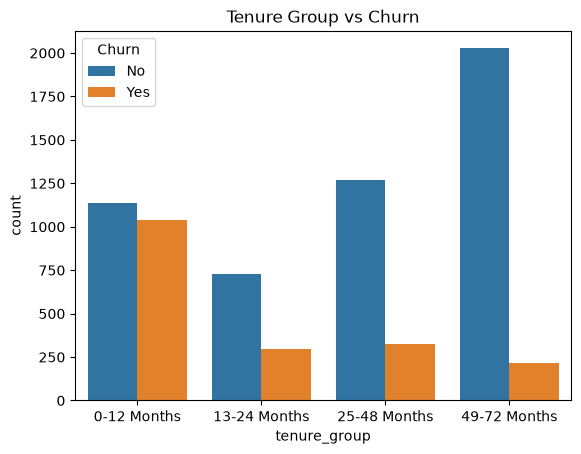


===== PhoneService =====
Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637

===== MultipleLines =====
Churn                    No        Yes
MultipleLines                         
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896

===== InternetService =====
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980

===== OnlineSecurity =====
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194

===== OnlineBackup =====
Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No 

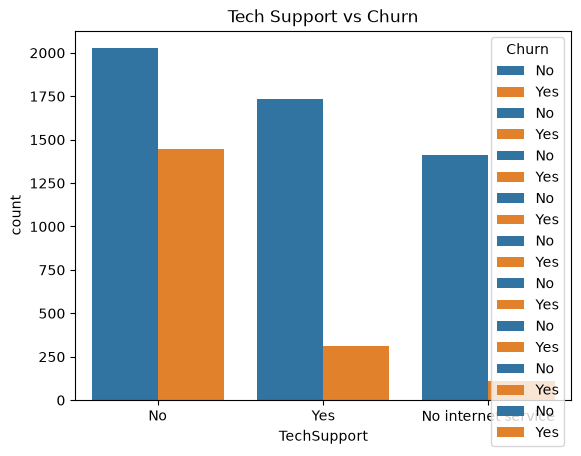

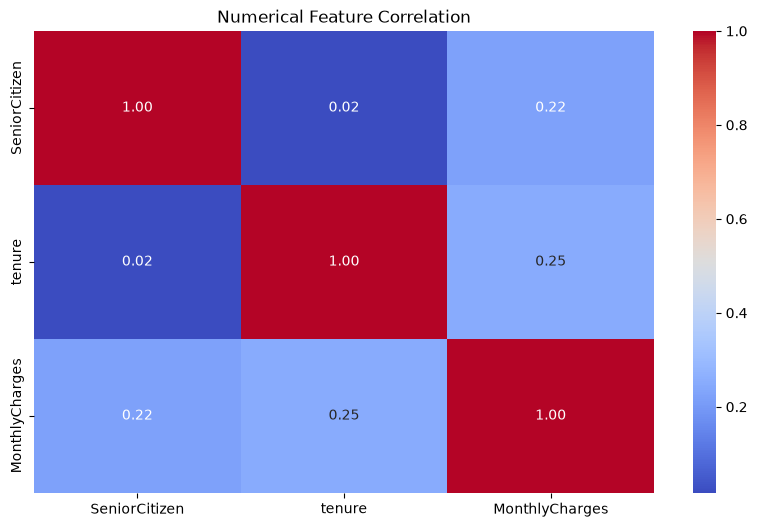

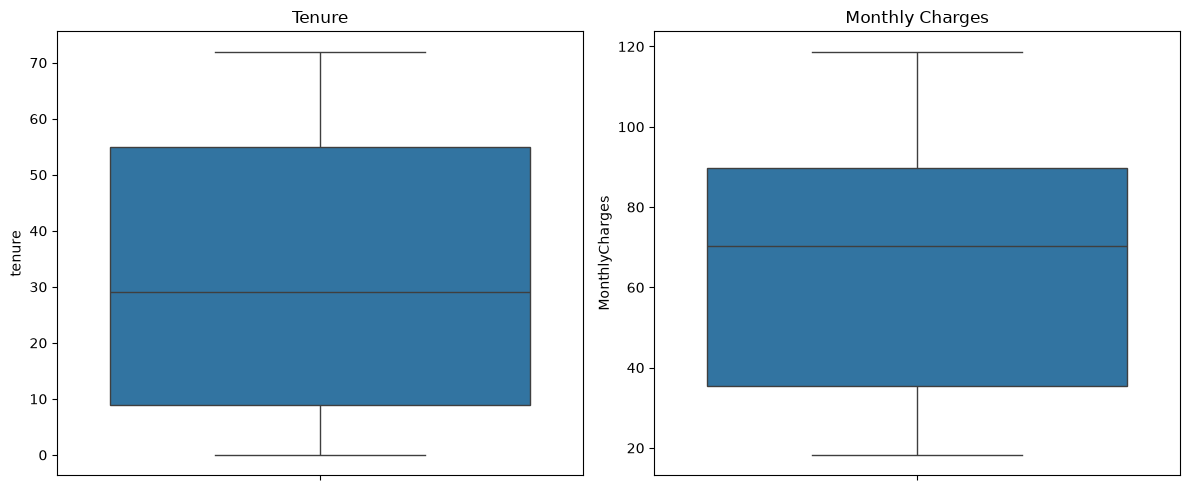

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully")
df = pd.read_csv(
    "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)
df.head()
df.shape
df.info()
df.describe(include="all").T
missing = df.isnull().sum()
missing[missing > 0]
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)
missing_percentage[missing_percentage > 0]
df["TotalCharges"].dtype
total_charges_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
total_charges_numeric.isnull().sum()
df.loc[
    total_charges_numeric.isnull(),
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]
df["Churn"].value_counts()
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()
churn_percentage = (
    df["Churn"].value_counts(normalize=True) * 100
)
churn_percentage
(
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .plot(kind="bar")
)
plt.title("Churn Percentage")
plt.ylabel("Percentage")
plt.xlabel("Churn")
plt.show()
numerical_columns = df.select_dtypes(
    include=np.number
).columns
numerical_columns
sns.histplot(
    data=df,
    x="tenure",
    kde=True
)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()
sns.histplot(
    data=df,
    x="MonthlyCharges",
    kde=True
)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()
sns.boxplot(
    data=df,
    x="MonthlyCharges"
)
plt.title("Monthly Charges — Boxplot")
plt.show()
categorical_columns = df.select_dtypes(
    include="object"
).columns
categorical_columns
df["Contract"].value_counts()
sns.countplot(
    data=df,
    x="Contract"
)
plt.title("Customer Contract Distribution")
plt.xticks(rotation=15)
plt.show()
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100
sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)
plt.title("Internet Service vs Churn")
plt.show()
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)
plt.title("Payment Method vs Churn")
plt.xticks(rotation=30)
plt.show()
pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100
sns.countplot(
    data=df,
    x="Partner",
    hue="Churn"
)
plt.title("Partner Status vs Churn")
plt.show()
pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100
sns.countplot(
    data=df,
    x="Dependents",
    hue="Churn"
)
plt.title("Dependents vs Churn")
plt.show()
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)
plt.title("Tenure vs Churn")
plt.show()
sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    kde=True,
    element="step"
)
plt.title("Tenure Distribution by Churn")
plt.show()
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)
plt.title("Monthly Charges vs Churn")
plt.show()
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)
df["tenure_group"].value_counts()
pd.crosstab(
    df["tenure_group"],
    df["Churn"],
    normalize="index"
) * 100
sns.countplot(
    data=df,
    x="tenure_group",
    hue="Churn"
)
plt.title("Tenure Group vs Churn")
plt.show()
service_columns = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]
for column in service_columns:
    print(f"\n===== {column} =====")
    print(
        pd.crosstab(
            df[column],
            df["Churn"],
            normalize="index"
        ) * 100
    )
    sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn"
)
plt.title("Tech Support vs Churn")
plt.show()
pd.crosstab(
    [df["Contract"], df["InternetService"]],
    df["Churn"],
    normalize="index"
) * 100
numeric_df = df.select_dtypes(include=np.number)
correlation = numeric_df.corr()
correlation
plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Numerical Feature Correlation")
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=df,
    y="tenure",
    ax=axes[0]
)
axes[0].set_title("Tenure")
sns.boxplot(
    data=df,
    y="MonthlyCharges",
    ax=axes[1]
)
axes[1].set_title("Monthly Charges")
plt.tight_layout()
plt.show()
# EDA Findings

## Target Variable

#- Churn is a binary classification target.
#- The classes are imbalanced.
#- Therefore accuracy alone should not be the primary evaluation metric.

## Customer Characteristics

#- [Write your observed finding]
#- [Write your observed finding]

## Contract

#- [Write your observed finding]
#- [Write your observed finding]

## Tenure

#- [Write your observed finding]
#- [Write your observed finding]

## Charges

#- [Write your observed finding]
#- [Write your observed finding]

## Services

#- [Write your observed finding]
#- [Write your observed finding]

## Data Quality

#- `TotalCharges` requires cleaning/conversion.
#- [Write other observations]

## Modeling Implications

#- Categorical variables will require encoding.
#- Numerical variables require appropriate preprocessing.
#- Identifier columns should be reviewed before modeling.
#- Class imbalance should be considered during model evaluation.

